In this notebook, we evaluate and compare supervised (ResNet) and unsupervised (VAE) approaches for detecting abnormal samples.


## Import

In [32]:
import torch
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score
from scipy.stats import norm

from tqdm.notebook import tqdm

In [2]:
import sys
import os
from typing import Literal

In [3]:
sys.path.append("../")

from utils.functions import set_random, low_pass_filter_fft, max_cosine_similarities, load_config
from src.models import Encoder, Decoder, ResNet18classification
from src.data_loading import load_labels, SpectralImagesUnsupervised, SpectralImagesSupervised
from src.train_unsupervised import base_transform

set_random(42)

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device = ', device)

device =  cuda:0


# VAE

## Data Loading

In [5]:
sys.path.append(os.getcwd())
#data_path = "..\Dataset"
data_path = "D:\GPUAccess\MohammadHadi_Salehi\Data_V4"
df = load_labels(data_path)

config_path = "..\src\config.yml"
config = load_config(config_path)

In [6]:
# inference_batch_size should be equal to the number of sensing units
# inference_batch_size = 21
inference_batch_size = config["hyperparameters"]["inference_batch_size"]


JAMMER_TYPES = ["barrage", "deceptive", "pilot", "sweep", "random_hop"]
NO_JAMMER = "no jammer"

def _make_loader(root, samples, load_dt_images=False):

    dataset = SpectralImagesUnsupervised(
        root,
        transform=base_transform,
        dataframe=samples,
        load_dt_images=load_dt_images,
    )

    data_loader = DataLoader(
        dataset,
        batch_size=inference_batch_size,
        shuffle=False,
        pin_memory=True,
        drop_last=False,
    )

    return data_loader

def get_eval_loaders(
    root,
    df: pd.DataFrame,
    split: Literal["valid", "test"],
    load_dt_images: bool = False,
) -> tuple[DataLoader, ...]:

    """
    Build evaluation DataLoaders for either the validation or test split.

    Parameters
    ----------
    root:            Dataset root directory.
    df:              Full metadata DataFrame.
    split:           "valid" → one normal loader;
                     "test"  → (normal loader, abnormal loader).
    load_dt_images:  Not implemented -> set as False

    Returns
    -------
    "valid" → (normal_loader,)
    "test"  → (normal_loader, abnormal_loader)
    """
    normal = df[df["jammer_type"] == NO_JAMMER]

    if split == "valid":
        num_train = int(config["unsupervised"]["num_train_normal"])
        num_valid = int(config["unsupervised"]["num_valid_normal"])
        samples = normal[num_train : num_train + num_valid]
        return _make_loader(root, samples, load_dt_images)

    if split == "test":
        num_normal  = int(config["unsupervised"]["num_test_normal"])
        num_anomaly = int(config["unsupervised"]["num_test_anomaly"])
        per_jammer  = num_anomaly // len(JAMMER_TYPES)

        normal_samples   = normal[-num_normal:]
        abnormal_samples = pd.concat(
            [df[df["jammer_type"] == j][-per_jammer:] for j in JAMMER_TYPES],
            ignore_index=True,
        )
        return (
            _make_loader(root, normal_samples,   load_dt_images),
            _make_loader(root, abnormal_samples, load_dt_images),
        )

    raise ValueError(f"Unknown split {split!r}. Expected 'valid' or 'test'.")

In [7]:
normal_valid = get_eval_loaders(data_path, df, "valid")

Caching images: 100%|██████████| 200/200 [00:16<00:00, 11.79it/s]

Sample Labels: 
 (array(['no jammer'], dtype='<U9'), array([4200]))
Jammer Classes: 
 (array([0]), array([4200]))


In [8]:
normal_test, abnormal_test = get_eval_loaders(data_path, df, "test")

Caching images: 100%|██████████| 1000/1000 [01:24<00:00, 11.85it/s]


Sample Labels: 
 (array(['no jammer'], dtype='<U9'), array([21000]))
Jammer Classes: 
 (array([0]), array([21000]))


Caching images: 100%|██████████| 2500/2500 [03:36<00:00, 11.54it/s]


Sample Labels: 
 (array(['barrage', 'deceptive', 'pilot', 'random_hop', 'sweep'],
      dtype='<U10'), array([10500, 10500, 10500, 10500, 10500]))
Jammer Classes: 
 (array([1, 2, 3, 4, 5]), array([10500, 10500, 10500, 10500, 10500]))


## Model Loading

In [9]:
encoder = Encoder()
decoder = Decoder()
    
encoder.load_state_dict(
    torch.load("..\\Weights\\OUT\\VAE_0412-213130\\encoder_final.pt", map_location = device, weights_only=True),
    strict=False
    )
decoder.load_state_dict(
    torch.load("..\\Weights\\OUT\\VAE_0412-213130\\decoder_final.pt", map_location = device, weights_only=True),
    strict=False
    )

<All keys matched successfully>

In [ ]:
encoder.to(device)
encoder.eval()

In [ ]:
decoder.to(device)
decoder.eval()

## Scores

Here we obtain two scores defined as $Rec\_Score$ \& $Latent\_Score$ for each sample in validation and test sets.

In [12]:
# -------------------------------------------
# Validation Set
# -------------------------------------------

S_v_l = []
S_v_r = []
with torch.inference_mode():
    for id_v, img, jammer, _, _  in tqdm(normal_valid):
        assert all(x[:6] == id_v[0][:6] for x in id_v), "Sensing units are from different sampels"
    
        img = img.float()
        img = img.to(device)
            
        mu, sigma = encoder(img)
        
        epsilon = torch.randn_like(sigma).to(device)
        z = mu + sigma * epsilon
        decoded_x = decoder(z)
        loss = img - decoded_x
        
        for i in range(loss.shape[0]):
            loss[i][0] = torch.tensor(low_pass_filter_fft(loss[i][0].cpu().numpy(), 15))
        
        latent_rep = mu.cpu().numpy()
        score_l = 1-(np.mean(max_cosine_similarities(latent_rep)))
        
        score_r = np.max(loss.cpu().numpy())

        S_v_l.append(score_l)
        S_v_r.append(score_r)

# Compute mean & standard deviation of the scores in the validation set
mu_l = np.mean(S_v_l)
std_l = np.sqrt(np.var(S_v_l))  
mu_r = np.mean(S_v_r)
std_r = np.sqrt(np.var(S_v_r))  

  0%|          | 0/200 [00:00<?, ?it/s]

In [13]:
Jammers = []
S_latent = []
S_rec = []
S_total = []


# -------------------------------------------
# Test Set
# -------------------------------------------

with torch.inference_mode():
    assert std_l != 0 and std_r != 0, "zero division"
        
    for id_v, img, jammer, _, _  in tqdm(abnormal_test): 
        assert all(x[:6] == id_v[0][:6] for x in id_v), "Sensing units are from different sampels"
        
        img = img.float()
        img = img.to(device)
            
        mu, sigma = encoder(img)
        
        epsilon = torch.randn_like(sigma).to(device)
        z = mu + sigma * epsilon
        decoded_x = decoder(z)
        loss = img - decoded_x
        
        for i in range(loss.shape[0]):
            loss[i][0] = torch.tensor(low_pass_filter_fft(loss[i][0].cpu().numpy(), 15))
            
        latent_rep = mu.cpu().numpy()
        score_l = 1-(np.mean(max_cosine_similarities(latent_rep)))
        
        score_r = np.max(loss.cpu().numpy())
        
        l = (score_l - mu_l) / std_l
        r = (score_r - mu_r) / std_r
        score = l + r
        
        S_total.append(score)
        S_latent.append(l)
        S_rec.append(r)
        
        if jammer[0] == 1:
            Jammers.append("Barrage")
            
        elif jammer[0] == 2:
            Jammers.append("Deceptive")
            
        elif jammer[0] == 3:
            Jammers.append("Pilot")
            
        elif jammer[0] == 4:
            Jammers.append("Sweep")
            
        elif jammer[0] == 5:
            Jammers.append("Random_hop")

    for id_v, img, jammer, _, _  in tqdm(normal_test):
        assert all(x[:6] == id_v[0][:6] for x in id_v), "Sensing units are from different sampels"
    
        img = img.float()
        img = img.to(device)
            
        mu, sigma = encoder(img)
        
        epsilon = torch.randn_like(sigma).to(device)
        z = mu + sigma * epsilon
        decoded_x = decoder(z)
        loss = img - decoded_x
        
        for i in range(loss.shape[0]):
            loss[i][0] = torch.tensor(low_pass_filter_fft(loss[i][0].cpu().numpy(), 15))
            
        latent_rep = mu.cpu().numpy()
        score_l = 1-(np.mean(max_cosine_similarities(latent_rep)))
        
        score_r = np.max(loss.cpu().numpy())
        
        l = (score_l - mu_l) / std_l
        r = (score_r - mu_r) / std_r
        score = l + r
        
        Jammers.append("Normal")
        S_total.append(score)
        S_latent.append(l)
        S_rec.append(r)

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

## Scores Distributions

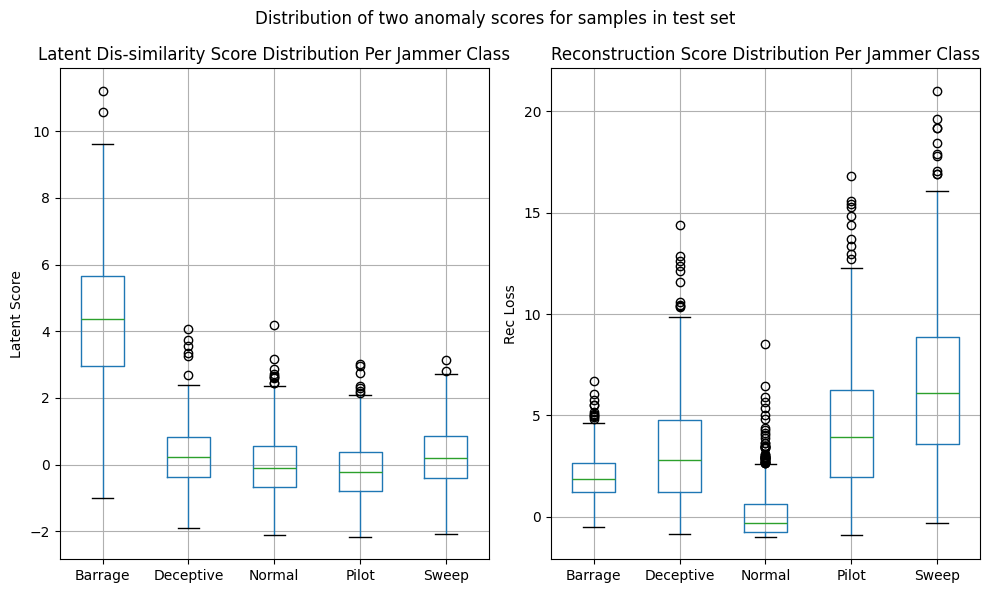

In [14]:
KNOWN_JAMMERS = ["Normal", "Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]


# -------------------------------------------
# Create dataframe from results
# -------------------------------------------

results_1 = pd.DataFrame({
    'value': [s for s,j in zip(S_latent, Jammers) if j in KNOWN_JAMMERS],
    'label': [j for j in Jammers if j in KNOWN_JAMMERS],
})

results_2 = pd.DataFrame({
    'value': [s for s,j in zip(S_rec, Jammers) if j in KNOWN_JAMMERS],
    'label': [j for j in Jammers if j in KNOWN_JAMMERS],
})


# -------------------------------------------
# Plot
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10,6), sharey=False)

results_1.boxplot(by='label', column='value', ax=axes[0])
axes[0].set_title("Latent Dis-similarity Score Distribution Per Jammer Class")
axes[0].set_xlabel("")
axes[0].set_ylabel("Latent Score")

results_2.boxplot(by='label', column='value', ax=axes[1])
axes[1].set_title("Reconstruction Score Distribution Per Jammer Class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rec Loss")

plt.suptitle("Distribution of two anomaly scores for samples in test set")

plt.tight_layout()
plt.show()

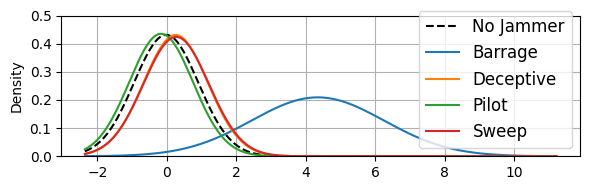

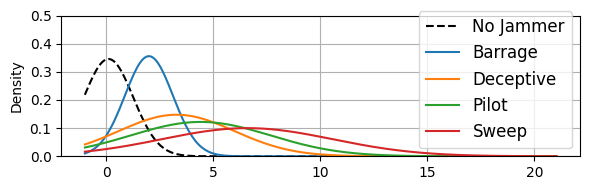

In [15]:
KNOWN_JAMMERS = ["Normal", "Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]


scores_r = np.array(S_rec)
scores_l = np.array(S_latent)

labels = np.array(Jammers)

# -------------------------------------------
# Fit normal distribution on results and plot
# -------------------------------------------

for scores, title, xlabel, filename in zip(
    [scores_l, scores_r],
    ["Latent Dissimilarity Score", "Maximum Reconstruction Error"],
    [r"normalized $a_\ell$", r"normalized $a_r$"],
    ["..\Figures\scores_dist_l.png", "..\Figures\scores_dist_r.png"]
):

    # Create a new figure each time
    fig, ax = plt.subplots(figsize=(6, 2))

    x_min, x_max = scores.min(), scores.max()
    x = np.linspace(x_min, x_max, 300)

    for lab in KNOWN_JAMMERS:
        data = scores[labels == lab]

        mu, sigma = data.mean(), data.std()
        y = norm.pdf(x, mu, sigma)

        if lab == "Normal":
            ax.plot(x, y, label="No Jammer", linestyle="--", color="k")
        else:
            ax.plot(x, y, label=lab)

    ax.set_ylabel("Density", fontsize=10)
    ax.set_ylim(0, 0.5)

    ax.legend(fontsize=12)
    ax.grid(True)

    plt.tight_layout()

    # Save each figure separately
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

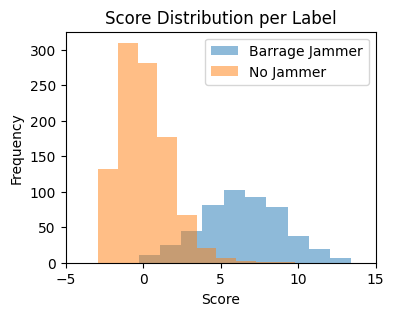

In [16]:
from collections import defaultdict

plt.figure(figsize=(4,3))

scores = np.array(S_total)
mask = (labels == "Normal") | (labels == "Barrage")
# group scores by label
grouped = defaultdict(list)
for l, s in zip(labels[mask], scores[mask]):
    grouped[l].append(s)

# plot
for label,( _ , vals) in zip(["Barrage", "Normal"], sorted(grouped.items())):
    category = "No Jammer" if label == "Normal" else "Barrage Jammer"
    plt.hist(vals, bins=10, alpha=0.5, label=category )

plt.xlabel("Score")
plt.xlim(-5, 15)
plt.ylabel("Frequency")
plt.legend()
plt.title("Score Distribution per Label")
plt.show()

## ROC_Curves

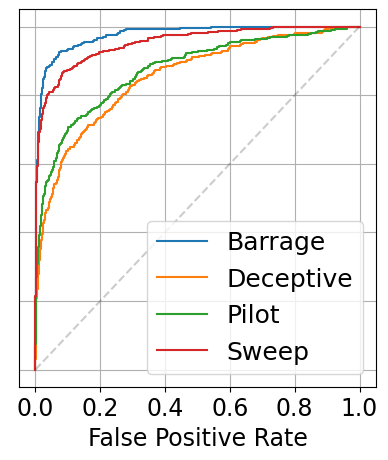

In [17]:
KNOWN_JAMMERS = ["Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]

scores = np.array(S_total)
labels = np.array(Jammers)


plt.figure(figsize=(4.6,4.9))
for cls in KNOWN_JAMMERS:
    # Binary labels: 1 = current anomaly class, 0 = normal
    mask = (labels == "Normal") | (labels == cls)
    
    y_true = (labels[mask] == cls).astype(int)
    y_scores = scores[mask]

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls}")

plt.plot([0, 1], [0, 1], linestyle="--", color="k", alpha=0.2)
plt.grid(True)
plt.xlabel("False Positive Rate", fontsize=17)

plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [' '] * 6)
plt.tick_params(axis='y', length=0)

plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.tick_params(axis='x', labelsize=17)

#plt.tight_layout()
plt.legend(fontsize=18, loc="lower right")
plt.savefig("..\Figures\AUC_VAE.png", dpi=300)
plt.show()

## Jammer Power

Here we show the relation between jammer power and detection quality of VAE for each jammer type

# ResNet

## Data Loading

In [18]:
sys.path.append(os.getcwd())
#data_path = "..\Dataset"
data_path = "D:\GPUAccess\MohammadHadi_Salehi\Data_V4"
df = load_labels(data_path)

config_path = "..\src\config.yml"
config = load_config(config_path)

In [19]:
inference_batch_size = 64


JAMMER_TYPES = ["barrage", "deceptive", "pilot", "sweep", "random_hop"]
NO_JAMMER = "no jammer"

def _make_loader(root, samples, load_dt_images=False):

    dataset = SpectralImagesSupervised(
        root,
        transform=base_transform,
        dataframe=samples,
        load_dt_images=load_dt_images,
    )

    data_loader = DataLoader(
        dataset,
        batch_size=inference_batch_size,
        shuffle=False,
        pin_memory=True,
        drop_last=False,
    )

    return data_loader

def get_eval_loaders_Sup(
    root,
    df: pd.DataFrame,
    load_dt_images: bool = False,
) -> tuple[DataLoader, ...]:

    """
    Build evaluation DataLoaders for supervised approach.

    Parameters
    ----------
    root:            Dataset root directory.
    df:              Full metadata DataFrame.
    split:           "valid" → one normal loader;
                     "test"  → (normal loader, abnormal loader).
    load_dt_images:  Not implemented -> set as False

    Returns
    -------
    "valid" → (normal_loader,)
    "test"  → (normal_loader, abnormal_loader)
    """
    normal = df[df["jammer_type"] == NO_JAMMER]

    num_normal  = int(config["supervised"]["num_test_normal"])
    num_anomaly = int(config["supervised"]["num_test_anomaly"])
    per_jammer  = num_anomaly // len(JAMMER_TYPES)

    normal_samples   = normal[-num_normal:]
    abnormal_samples = pd.concat(
        [df[df["jammer_type"] == j][-per_jammer:] for j in JAMMER_TYPES],
        ignore_index=True,
    )
    test_samples = pd.concat(
        [normal_samples, abnormal_samples],
        ignore_index=True
    )
    return _make_loader(root, test_samples,   load_dt_images)

In [20]:
test_data = get_eval_loaders_Sup(data_path, df)

Caching images: 100%|██████████| 3500/3500 [04:12<00:00, 13.85it/s]

Labels: 
 (array(['barrage', 'deceptive', 'no jammer', 'pilot', 'random_hop',
       'sweep'], dtype='<U10'), array([ 500,  500, 1000,  500,  500,  500]))
Jammer Classes: 
 (array([0, 1, 2, 3, 4, 5]), array([1000,  500,  500,  500,  500,  500]))


## Model Loading

In [21]:
classifier = ResNet18classification()
classifier.load_state_dict(
    torch.load(
        "..\\Weights\\OUT\\Res_0421-184702\\final_model.pth",
        map_location = device, weights_only=True
        ), strict=False
    )

<All keys matched successfully>

In [22]:
classifier.to(device)
classifier.eval()

ResNet18classification(
  (model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

## Detection and Anomaly Score

Here, we obtain the probability assigned by the ResNet model for each sample being an anomaly. Also, we map each probability into binary prediction by $Threshold=0.5$ .

In [23]:
Res_prediction = []
Res_Label = []
Res_score = []

with torch.no_grad():
    for _, orig_img, label, _, _  in tqdm(test_data):

        orig_img = orig_img.to(device).float()
        
        label = label.to(device).float()

        outputs = classifier(orig_img).squeeze(1)

        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).int()
        
        Res_Label.extend(label.cpu().numpy().tolist())
        Res_prediction.extend(predicted.cpu().numpy().tolist())
        Res_score.extend(probs.cpu().numpy().tolist())

  0%|          | 0/55 [00:00<?, ?it/s]

## Score Distributions

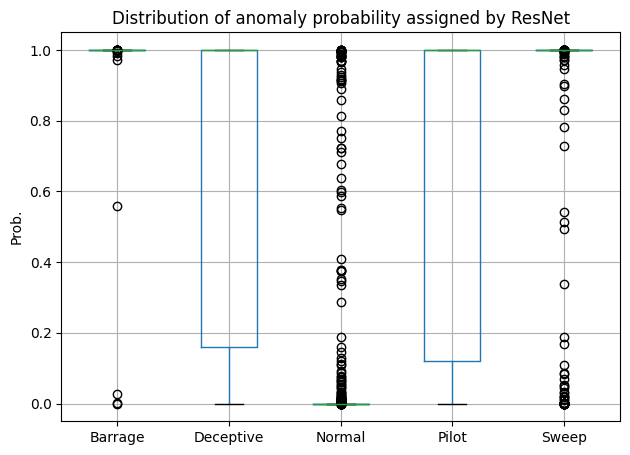

In [24]:
Res_Jammer_Label = []

for jammer in Res_Label:
    if jammer == 0:
        Res_Jammer_Label.append("Normal")

    elif jammer == 1:
        Res_Jammer_Label.append("Barrage")
        
    elif jammer == 2:
        Res_Jammer_Label.append("Deceptive")
        
    elif jammer == 3:
        Res_Jammer_Label.append("Pilot")
        
    elif jammer == 4:
        Res_Jammer_Label.append("Sweep")
        
    elif jammer == 5:
        Res_Jammer_Label.append("Random_hop")


KNOWN_JAMMERS = ["Normal", "Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]


# -------------------------------------------
# Create dataframe from results
# -------------------------------------------

results_Res = pd.DataFrame({
    'value': [s for s,j in zip(Res_score, Res_Jammer_Label) if j in KNOWN_JAMMERS],
    'label': [j for j in Res_Jammer_Label if j in KNOWN_JAMMERS],
})


# -------------------------------------------
# Plot
# -------------------------------------------

results_Res.boxplot(by='label', column='value')
plt.title("Distribution of anomaly probability assigned by ResNet")
plt.xlabel("")
plt.ylabel("Prob.")
plt.suptitle("")

plt.tight_layout()
plt.show()

## ROC_Curves

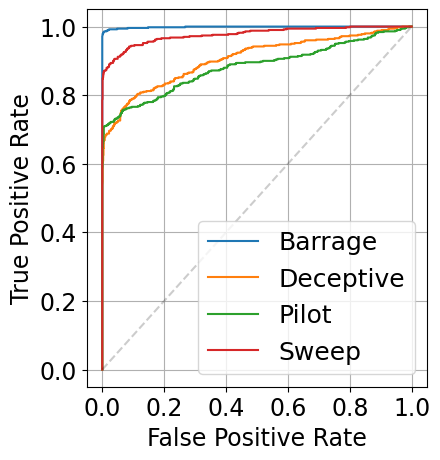

In [25]:
KNOWN_JAMMERS = ["Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]


labels = np.array(Res_Label)
S = np.array(Res_score)

plt.figure(figsize=(4.6,4.9))
for i, cls in enumerate(KNOWN_JAMMERS):
    
    mask = (labels == 0) | (labels == i+1)
    
    y_true = (labels[mask] == i+1).astype(int)
    y_scores = S[mask]

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls}")

plt.plot([0, 1], [0, 1], linestyle="--", color="k", alpha=0.2)
plt.grid(True)
#plt.title("ROC Curves (ResNet)")
plt.xlabel("False Positive Rate", fontsize=17)
plt.ylabel("True Positive Rate", fontsize=17)
plt.subplots_adjust(left=0.16)

plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.tick_params(axis='y', labelsize=17)

plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.tick_params(axis='x', labelsize=17)

#plt.tight_layout()
plt.legend(fontsize=18, loc="lower right")
plt.savefig("..\\Figures\\AUC_ResNet.png", dpi=300)
plt.show()

## Jammer Power

Here we show the relation between jammer power and detection quality of Supervised model for each jammer type

# Compare

Here we compare two models based on their ability to detect an Unknown jammer type (Random Hop Jammer) .


**To execute the below cells, please first obtain the scores from previous sections.**

## ROC Curves

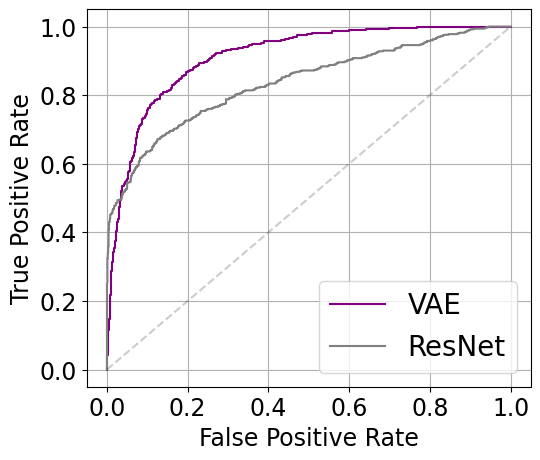

In [ ]:
scores_VAE = np.array(S_total)
labels_VAE = np.array(Jammers)

scores_Res = np.array(Res_score)
labels_Res = np.array(Res_Jammer_Label)

plt.figure(figsize=(6,4.9))
mask = (labels_VAE == "Normal") | (labels_VAE == "Random_hop")

y_true = (labels_VAE[mask] == "Random_hop").astype(int)
y_scores = scores_VAE[mask]

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"VAE", color = "purple")

    
mask = (labels_Res == "Normal") | (labels_Res == "Random_hop")

y_true = (labels_Res[mask] == "Random_hop").astype(int)
y_scores = scores_Res[mask]

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ResNet", color = "gray")


plt.plot([0, 1], [0, 1], linestyle="--", color="k", alpha=0.2)
plt.grid(True)
plt.xlabel("False Positive Rate", fontsize=17)
plt.ylabel("True Positive Rate", fontsize=17)
plt.subplots_adjust(left=0.16)

plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.tick_params(axis='y', labelsize=17)

plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.tick_params(axis='x', labelsize=17)

plt.legend(fontsize=20, loc="lower right")
plt.savefig("..\\Figures\\AUC_compare.png", dpi=300)
plt.show()


## F1 Score

In [34]:
KNOWN_JAMMERS = ["Barrage", "Deceptive", "Pilot", "Sweep"]
UNKNOWN_JAMMER = ["Random_hop"]

Unsupervised (VAE)

In [35]:
def compute_threshold(val_scores, percentile=95):
    """
    val_scores: list or numpy array of validation scores (normal samples)
    percentile: percentile to compute (default 95)
    """
    threshold = np.percentile(val_scores, percentile)
    return threshold

In [40]:
val_scores = (np.array(S_v_l) - mu_l) / std_l + (np.array(S_v_r) - mu_r) / std_r
threshold = compute_threshold(val_scores, 90)
print("Threshold (90th percentile):", threshold)

scores_VAE = np.array(S_total)
labels_VAE = np.array(Jammers)

for jammer in KNOWN_JAMMERS:
    mask = (labels_VAE == "Normal") | (labels_VAE == jammer)
    y_true = (labels_VAE[mask] == jammer).astype(int)
    y_pred = (scores_VAE[mask] > threshold).astype(int)

    f1_jammer = f1_score(y_true, y_pred)

    print(f"F1 Score for jammer {jammer}:", f1_jammer)

for jammer in UNKNOWN_JAMMER:
    mask = (labels_VAE == "Normal") | (labels_VAE == jammer)
    y_true = (labels_VAE[mask] == jammer).astype(int)
    y_pred = (scores_VAE[mask] > threshold).astype(int)

    f1_jammer = f1_score(y_true, y_pred)

    print(f"\nF1 Score for a new jammer {jammer}:", f1_jammer)
    

Threshold (90th percentile): 2.1210985
F1 Score for jammer Barrage: 0.8739495798319328
F1 Score for jammer Deceptive: 0.6948051948051948
F1 Score for jammer Pilot: 0.7384937238493724
F1 Score for jammer Sweep: 0.8403846153846154

F1 Score for a new jammer Random_hop: 0.774390243902439


Supervised (ResNet)

In [41]:
preds_Res = np.array(Res_prediction)
labels_Res = np.array(Res_Jammer_Label)


for jammer in KNOWN_JAMMERS:
    mask = (labels_Res == "Normal") | (labels_Res == jammer)
    y_true = (labels_Res[mask] == jammer).astype(int)
    y_pred = preds_Res[mask]

    f1_jammer = f1_score(y_true, y_pred)

    print(f"F1 Score for jammer {jammer}:", f1_jammer)

for jammer in UNKNOWN_JAMMER:
    mask = (labels_Res == "Normal") | (labels_Res == jammer)
    y_true = (labels_Res[mask] == jammer).astype(int)
    y_pred = preds_Res[mask]

    f1_jammer = f1_score(y_true, y_pred)

    print(f"\nF1 Score for a new jammer {jammer}:", f1_jammer)
    

F1 Score for jammer Barrage: 0.9493791786055397
F1 Score for jammer Deceptive: 0.793859649122807
F1 Score for jammer Pilot: 0.7991266375545851
F1 Score for jammer Sweep: 0.9054726368159204

F1 Score for a new jammer Random_hop: 0.653610771113831
